<a href="https://colab.research.google.com/github/starsyntaxx/agri_guard/blob/main/model_selection/notebooks/03_ttm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Zero-shot Evaluation on TTM model using Synthetic data**

In [13]:
!pip install -U huggingface_hub

In [14]:
from huggingface_hub import snapshot_download

model_path = snapshot_download(
    repo_id="ibm-granite/granite-timeseries-ttm-r3"
)

print(model_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/models--ibm-granite--granite-timeseries-ttm-r3/snapshots/ea17cfd2e3edcaea21eb8dcecd18bf88971482fa


In [15]:
import os

for file in os.listdir(model_path):
    print(file)

model.safetensors
README.md
.gitattributes
ttm_image.webp
config.json
model.sig


In [ ]:
!pip install -q pandas==2.2.3

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoConfig
from transformers import AutoModelForCausalLM

In [5]:
np.random.seed(42)

# Create 200 hourly observations
n = 200

timestamps = pd.date_range(
    start="2025-01-01",
    periods=n,
    freq="h"
)

# Synthetic sensor signal:
# - baseline
# - gradual trend
# - daily pattern
# - small random noise
time = np.arange(n)

values = (
    50
    + 0.02 * time
    + 3 * np.sin(2 * np.pi * time / 24)
    + np.random.normal(0, 0.5, n)
)

df = pd.DataFrame({
    "timestamp": timestamps,
    "value": values
})

df.head()

,timestamp,value
0,2025-01-01 00:00:00,50.248357
1,2025-01-01 01:00:00,50.727325
2,2025-01-01 02:00:00,51.863844
3,2025-01-01 03:00:00,52.942835
4,2025-01-01 04:00:00,52.561000


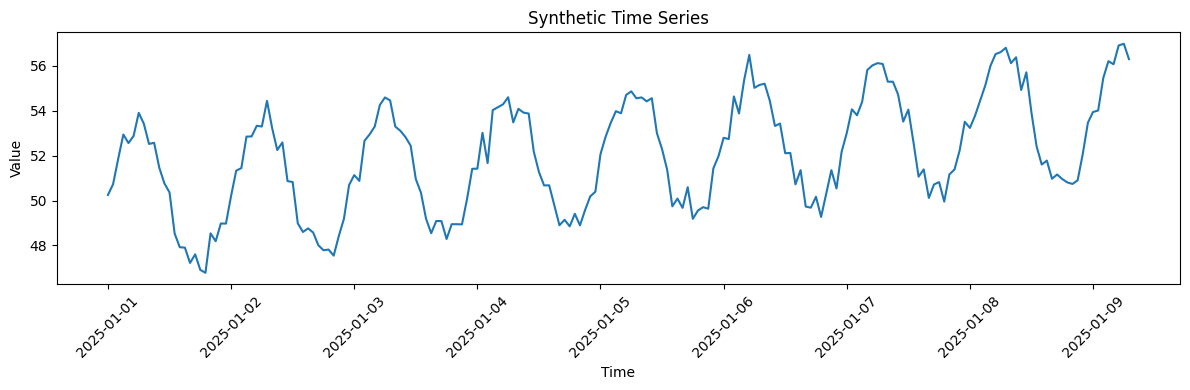

In [6]:
plt.figure(figsize=(12, 4))

plt.plot(df["timestamp"], df["value"])

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Synthetic Time Series")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
context_length = 96
forecast_length = 24

In [17]:
!pip install -q -U "granite-tsfm"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 27.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [16]:
config = AutoConfig.from_pretrained(model_path)

print(config)

ValueError: The checkpoint you are trying to load has model type `tinytimemixer` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True
)

print(type(model))